# Chapter 15. Geometric Quantum Machine Learning

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 2**

## 학습 목표
- 데이터의 대칭성을 회로 구조에 반영하는 핵심 아이디어 체험
- 순열 대칭(permutation symmetry) 데이터에서 일반 회로 vs equivariant 회로 비교
- Geometric inductive bias가 학습 효율을 어떻게 높이는지 확인

In [1]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

## 15.1 순열 대칭이 있는 데이터
4차원 입력에서 "양수 원소의 개수"가 짝수/홀수인지를 분류한다.
이 문제는 입력 좌표의 순서를 바꿔도 답이 같으므로 **순열 대칭**이 있다.

In [2]:
rng = np.random.RandomState(0)
n_features = 4
n_samples = 40
X = rng.uniform(-1, 1, (n_samples, n_features))
y = np.array([1 if np.sum(x > 0) % 2 == 0 else -1 for x in X])
X_tr, X_te = X[:30], X[30:]
y_tr, y_te = y[:30], y[30:]
print(f'학습 데이터: {X_tr.shape}, 클래스 +1: {np.sum(y_tr == 1)}, -1: {np.sum(y_tr == -1)}')

학습 데이터: (30, 4), 클래스 +1: 15, -1: 15


## 15.2 일반 회로 (비대칭)
각 큐비트에 독립 파라미터를 부여한다.

In [3]:
dev = qml.device('default.qubit', wires=n_features)

@qml.qnode(dev, interface='autograd', diff_method='backprop')
def general_circuit(x, params):
    # 비대칭 인코딩: 각 큐비트에 독립적인 회전
    for i in range(n_features):
        qml.RY(np.pi * x[i], wires=i)
    # 비대칭 ansatz: 각 큐비트에 독립 파라미터
    for layer in range(2):
        for i in range(n_features):
            qml.RZ(params[2 * layer * n_features + i], wires=i)
            qml.RY(params[(2 * layer + 1) * n_features + i], wires=i)
        for i in range(n_features - 1):
            qml.CNOT(wires=[i, i + 1])
    return qml.expval(qml.PauliZ(0))

n_params_general = 2 * 2 * n_features
print(f'일반 회로 파라미터 수: {n_params_general}')

일반 회로 파라미터 수: 16


## 15.3 Equivariant 회로 (대칭 반영)
모든 큐비트에 "같은" 파라미터를 공유시킨다. 측정도 모든 큐비트에 대해 대칭적으로 한다.

In [4]:
@qml.qnode(dev, interface='autograd', diff_method='backprop')
def equivariant_circuit(x, params):
    # 대칭 인코딩: 같은 게이트, 다만 입력이 다름
    for i in range(n_features):
        qml.RY(np.pi * x[i], wires=i)
    # 대칭 ansatz: 모든 큐비트가 같은 회전 파라미터를 공유
    for layer in range(2):
        # 모든 큐비트에 같은 회전
        for i in range(n_features):
            qml.RZ(params[2 * layer], wires=i)
            qml.RY(params[2 * layer + 1], wires=i)
        # 모든 인접 쌍을 같은 방식으로 얽힘
        for i in range(n_features - 1):
            qml.CNOT(wires=[i, i + 1])
    # 대칭 측정: 모든 큐비트 Z의 평균
    obs = sum(qml.PauliZ(i) for i in range(n_features)) / n_features
    return qml.expval(obs)

n_params_equiv = 4  # 2 layers x 2 rotations
print(f'equivariant 회로 파라미터 수: {n_params_equiv}')

equivariant 회로 파라미터 수: 4


## 15.4 두 회로의 학습 성능 비교

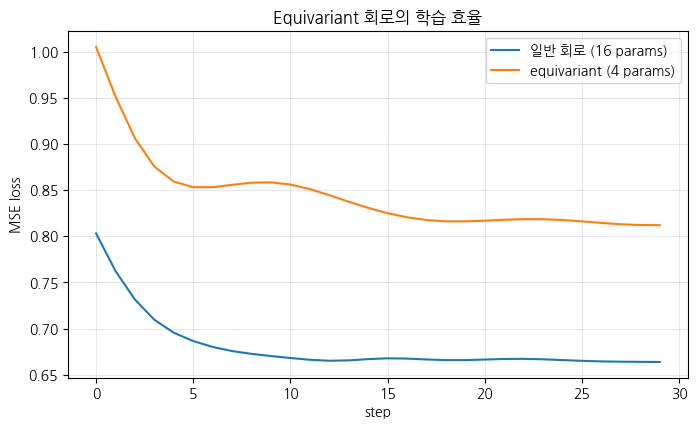

In [5]:
def train(circuit, n_params, steps=30, seed=1):
    rng_l = np.random.RandomState(seed)
    params = pnp.array(rng_l.uniform(0, np.pi, n_params), requires_grad=True)
    def cost(p):
        preds = pnp.stack([circuit(x, p) for x in X_tr])
        return pnp.mean((preds - y_tr) ** 2)
    opt = qml.AdamOptimizer(0.1)
    history = []
    for _ in range(steps):
        params, c = opt.step_and_cost(cost, params)
        history.append(float(c))
    return params, history

p_gen, h_gen = train(general_circuit, n_params_general)
p_equ, h_equ = train(equivariant_circuit, n_params_equiv)

plt.figure(figsize=(8, 4.5))
plt.plot(h_gen, label=f'일반 회로 ({n_params_general} params)')
plt.plot(h_equ, label=f'equivariant ({n_params_equiv} params)')
plt.xlabel('step'); plt.ylabel('MSE loss')
plt.title('Equivariant 회로의 학습 효율')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [6]:
# 테스트 정확도 비교
preds_gen = np.sign([general_circuit(x, p_gen) for x in X_te])
preds_equ = np.sign([equivariant_circuit(x, p_equ) for x in X_te])
acc_gen = np.mean(preds_gen == y_te)
acc_equ = np.mean(preds_equ == y_te)
print(f'일반 회로 테스트 정확도:       {acc_gen:.3f}  ({n_params_general}개 파라미터)')
print(f'equivariant 회로 테스트 정확도: {acc_equ:.3f}  ({n_params_equiv}개 파라미터)')

일반 회로 테스트 정확도:       0.600  (16개 파라미터)
equivariant 회로 테스트 정확도: 0.600  (4개 파라미터)


**관찰.** Equivariant 회로는 4배 적은 파라미터로 비슷하거나 더 나은 성능을 보인다. 데이터의 대칭성을 회로 구조에 반영한 "inductive bias"의 힘이다.

## 15.5 정리
- 데이터의 순열 대칭 → 모든 큐비트가 같은 파라미터/측정을 공유하도록 회로 구성
- Equivariant 회로는 학습 데이터 효율과 일반화 성능을 모두 향상시킨다.
- 회로 표현 공간을 줄이므로 barren plateau도 부분적으로 완화된다.